In [20]:
import numpy as np
import pandas as pd
import os 
import math
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir('../../')
from load import load_bin_dir_to_ratio
from metric import calculate_correlation_with_groundtruth, calculate_precision_racall, calculate_dict_correlation
from binlib import output_bin

ref_genome_folder = 'Data/ref_genome/hg19'
exclude_chr = ['chrM', 'chrY', 'chrMT']
resolution = 50000

# load ref genome length info
chr_length = dict()
with open(ref_genome_folder + '/hg19.len', 'r') as f:
    lines = f.read().splitlines()
    for line in lines:
        chr_name , len_ = line.split('\t')[:2]
        if chr_name in exclude_chr:
            continue
        chr_length[chr_name] = int(len_)
print('chr length : \n',chr_length)

# calculate bin number in each chr
chr_bin_number = dict()
for key in chr_length.keys():
    chr_bin_number[key] = math.floor(chr_length[key] / resolution) + 1
print('chr bin number : \n', chr_bin_number)

# back to current dir
os.chdir('Exps/exp11_smooth')

chr length : 
 {'chr1': 249250621, 'chr2': 243199373, 'chr3': 198022430, 'chr4': 191154276, 'chr5': 180915260, 'chr6': 171115067, 'chr7': 159138663, 'chr8': 146364022, 'chr9': 141213431, 'chr10': 135534747, 'chr11': 135006516, 'chr12': 133851895, 'chr13': 115169878, 'chr14': 107349540, 'chr15': 102531392, 'chr16': 90354753, 'chr17': 81195210, 'chr18': 78077248, 'chr19': 59128983, 'chr20': 63025520, 'chr21': 48129895, 'chr22': 51304566, 'chrX': 155270560}
chr bin number : 
 {'chr1': 4986, 'chr2': 4864, 'chr3': 3961, 'chr4': 3824, 'chr5': 3619, 'chr6': 3423, 'chr7': 3183, 'chr8': 2928, 'chr9': 2825, 'chr10': 2711, 'chr11': 2701, 'chr12': 2678, 'chr13': 2304, 'chr14': 2147, 'chr15': 2051, 'chr16': 1808, 'chr17': 1624, 'chr18': 1562, 'chr19': 1183, 'chr20': 1261, 'chr21': 963, 'chr22': 1027, 'chrX': 3106}


In [75]:
bin_dir = '../../CNV/K562_HIC_CNV/HiNTcnv_OUTPUT_K562_HindIII/segmentation/b50000'

res_dict = dict()
for key in chr_bin_number.keys():
    res_dict[key] = np.zeros(chr_bin_number[key])

keys = list(chr_bin_number.keys())
key_num = 0
for file in sorted(os.listdir(bin_dir)):
    with open(f'{bin_dir}/{file}', 'r') as f:
        for line in f.readlines()[1:]:
            start_, end_, obs, exp ,var = line.strip().split()
            residual = float(obs) - float(exp)
            bin_ = math.floor(int(start_)/resolution)
            res_dict[keys[key_num]][bin_] = residual
    key_num = key_num +1


In [80]:
def filter_outlier(signal, max = 4, min = -4):
    filtered_signal = np.zeros(len(signal))
    for i in range(len(signal)):
        if  signal[i] > max :
            filtered_signal[i] = max
        elif signal[i] < min :
            filtered_signal[i] = min
        else:
            filtered_signal[i] = signal[i]
    return filtered_signal

In [163]:
def mean_filter_1d(signal, win_size = 5):
    smoothed_signal = np.zeros(len(signal))
    for i in range(len(signal)):
        start_ = i - math.floor(win_size/2) if i - math.floor(win_size/2) >=0 else 0 
        end_ = i + math.floor(win_size/2) if i + math.floor(win_size/2) <= len(signal) -1  else len(signal) -1
        win_ = signal[start_:end_+1]
        smoothed_signal[i] = np.mean(win_)
    return smoothed_signal

In [164]:
def median_filter_1d(signal, win_size = 5):
    smoothed_signal = np.zeros(len(signal))
    for i in range(len(signal)):
        start_ = i - math.floor(win_size/2) if i - math.floor(win_size/2) >=0 else 0 
        end_ = i + math.floor(win_size/2) if i + math.floor(win_size/2) <= len(signal) -1  else len(signal) -1
        win_ = signal[start_:end_+1]
        smoothed_signal[i] = np.median(win_)
    return smoothed_signal

In [221]:
from scipy.signal import savgol_filter


### perform smoothing in defferent window size

In [ ]:
win_size_list = [3,5,7,11,21,41]
for win_size in win_size_list:
    moving_avg_res_dict = dict()
    for chr_ in chr_bin_number.keys():
        moving_avg_res_dict[chr_] = savgol_filter(filter_outlier(res_dict[chr_]), win_size, 2)
            

    #output .bw for visualization
    output_path = f'hic_residual_pool_win{win_size}.bw'
    with open(output_path, 'w+') as f:
        for key in moving_avg_res_dict.keys():
            for bin_, residual in enumerate(moving_avg_res_dict[key]):
                bin_start = bin_ * 50000
                bin_end = (bin_+1) * 50000 if (bin_+1) * 50000 <= chr_length[key] else chr_length[key]
                f.write(f'{key}\t{bin_start}\t{bin_end}\t{residual}\n')

    ### output for BICseq-seg
    output_bin(moving_avg_res_dict, f'win{win_size}')

### calculate log2 residual ratio corr.

In [219]:
for win_size in win_size_list:
    print(f'win {win_size}')
    hic_log2_ratio_dict = load_bin_dir_to_ratio(f'win{win_size}')
    wgs_log2_ratio_dict = load_bin_dir_to_ratio('../../CNV/WGS/K562/BICseq2/bin')
    calculate_dict_correlation(hic_log2_ratio_dict, wgs_log2_ratio_dict)

win 3
Pearson corr. :  0.629
Spearman corr. :  0.801
win 5
Pearson corr. :  0.603
Spearman corr. :  0.816
win 7
Pearson corr. :  0.629
Spearman corr. :  0.819
win 11
Pearson corr. :  0.616
Spearman corr. :  0.823
win 21
Pearson corr. :  0.581
Spearman corr. :  0.831
win 41
Pearson corr. :  0.625
Spearman corr. :  0.837


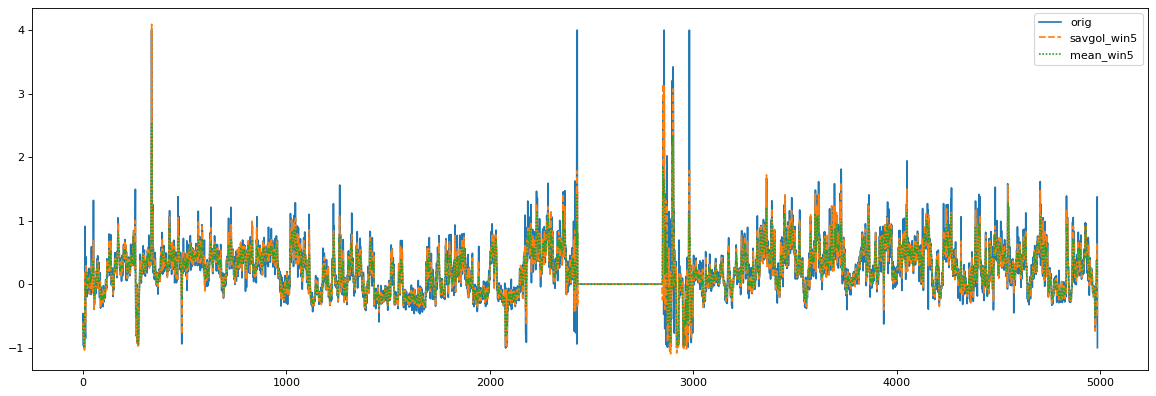

In [207]:

smooth_res_list = list()
smooth_res_list.append(filter_outlier(res_dict['chr1']))
smooth_res_list.append(savgol_filter(filter_outlier(res_dict['chr1']), 5, 2))
smooth_res_list.append(mean_filter_1d(filter_outlier(res_dict['chr1']), win_size=5))

smooth_res = pd.DataFrame(np.transpose(smooth_res_list), columns=['orig','savgol_win5', 'mean_win5'])

fig = plt.figure(figsize=(18, 6), dpi=80)
orig = sns.lineplot(data=smooth_res) 
plt.show()

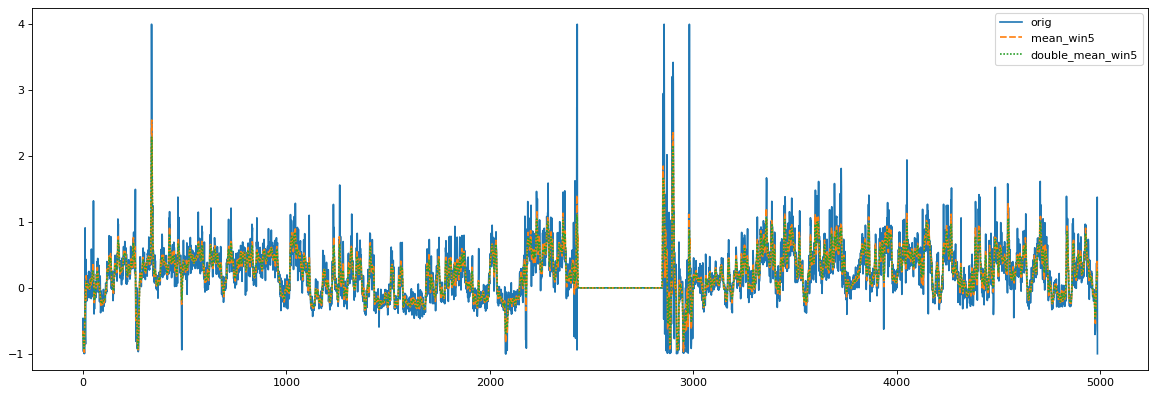

In [209]:

smooth_res_list = list()
smooth_res_list.append(filter_outlier(res_dict['chr1']))
smooth_res_list.append(mean_filter_1d(filter_outlier(res_dict['chr1']), win_size=5))
smooth_res_list.append(mean_filter_1d(mean_filter_1d(filter_outlier(res_dict['chr1']), win_size=5),win_size=5))

smooth_res = pd.DataFrame(np.transpose(smooth_res_list), columns=['orig','mean_win5', 'double_mean_win5'])

fig = plt.figure(figsize=(18, 6), dpi=80)
orig = sns.lineplot(data=smooth_res) 
plt.show()